---
## Reavaliação do dataset Iris
*Nome:* Livia Keche de Oliveira
*Período e turma:* 6A
*Turno:* Manhã

Este notebook foi desenvolvido para a atividade de reavaliação utilizando dados obtidos diretamente do Kaggle via repositório `menegidio/iris-species`.

# Workflow do Projeto conforme enunciado do teams
1. Carregamento dos dados locais do Kaggle
2. Análise Exploratória de Dados (EDA)
3. Pré-processamento e Padronização
4. Treinamento de SVM (Linear, RBF e Polinomial)
5. Otimização de Hiperparâmetros (C e Gamma)
6. Avaliação e Comparação de Métricas
7. Documentação

In [1]:
# Imports ensinados em aula para esse modelo
# Funções do scikit-learn (nossa caixa de ferramentas) para divisão de dados, padronização e modelos
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import os
for dirname, _,filenames in os.walk('/kaggle/input/datasets/menegidio/iris-species'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Configuração para que os gráficos fiquem em um tamanho bom de ler
plt.rcParams["figure.figsize"] = (6, 4)
df= pd.read_csv('/kaggle/input/datasets/menegidio/iris-species/Iris.csv')
df.head()

/kaggle/input/datasets/menegidio/iris-species/Iris.csv
/kaggle/input/datasets/menegidio/iris-species/database.sqlite


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


---
# Análise Exploratória de Dados (EDA)
Antes de rodar um modelo de **I.A**, é preciso preciso entender com o que está trabalhando, então verifico a quantidade de linhas e colunas, os nomes das variáveis, a existência de valores nulos e se as espécies de flores estão bem distribuídas. Além de criar um gráfico para ver visualmente a separação das flores.

Formato do dataset: (150, 6)

 Informações das Colunas
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

 Contagem por Espécie 
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


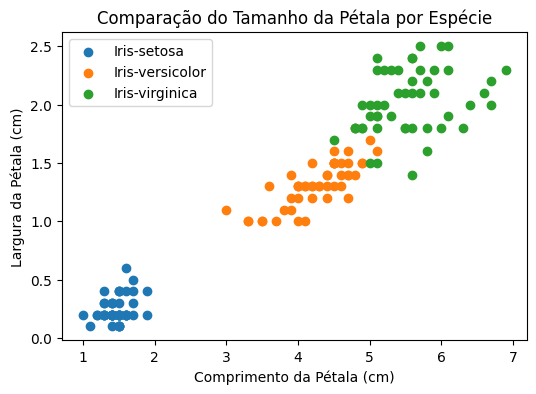

In [2]:
# Mostra (linhas, colunas)
print("Formato do dataset:", df.shape)

# Informações sobre os tipos de dados e se há valores faltando (null)
print("\n Informações das Colunas")
df.info()

# Quantas flores de cada espécie temos na tabela
print("\n Contagem por Espécie ")
print(df['Species'].value_counts())

# Gráfico para ver a relação entre o tamanho e a largura das pétalas
plt.figure()
for especie, dados_especie in df.groupby('Species'):
    plt.scatter(dados_especie['PetalLengthCm'], dados_especie['PetalWidthCm'], label=especie)

plt.xlabel('Comprimento da Pétala (cm)')
plt.ylabel('Largura da Pétala (cm)')
plt.title('Comparação do Tamanho da Pétala por Espécie')
plt.legend()
plt.show()

---
# Preparação dos Dados: Divisão entre Treino e Teste
Para ensinar e testar o algoritmo de forma justa, separo meus dados em duas partes:Entradas ($X$): As 4 medidas da flor (**SepalLengthCm**, **SepalWidthCm**, **PetalLengthCm**, **PetalWidthCm**).**Saída ($y$)**: O nome da espécie (**Species**). Uso a medida padrão de divisão para treino e teste, *80/20*. O uso do **stratify=y** garante que a proporção de cada espécie continue igual nas duas partes.

In [3]:
# X pega todas as colunas exceto 'Species'
X = df.drop(columns=['Species'])

# y pega apenas a coluna com o resultado esperado
y = df['Species']

# Divisão dos dados em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Total de amostras para treino: {X_train.shape[0]}")
print(f"Total de amostras para teste: {X_test.shape[0]}")

Total de amostras para treino: 120
Total de amostras para teste: 30


---
# Experimento 1: Treinando um SVM Linear com Pipeline
O modelo **SVM** (Support Vector Machine) tenta traçar uma *linha/hiperplano* para separar as classes.

O SVM funciona melhor quando todas as variáveis estão na mesma escala. Por isso, uso um Pipeline, que junta duas etapas:

    `StandardScaler()`: Padroniza os dados (coloca na mesma escala).
    `SVC(kernel='linear')`: Treina o classificador usando uma reta simples para separar as espécies.

In [4]:
# Criando o fluxo de trabalho (Pipeline)
pipeline_linear = Pipeline([
    ('escalonador', StandardScaler()), # 1º Coloca os dados na mesma escala
    ('modelo_svm', SVC(kernel='linear', C=1.0, random_state=42)) # 2º Aplica o SVM linear
])

# Treinando o modelo com as flores do grupo de treino
pipeline_linear.fit(X_train, y_train)

# Fazendo previsões para as flores do grupo de teste (NÃO VISTO PELO MODELO)
previsoes_linear = pipeline_linear.predict(X_test)

# Calculando a acurácia
acuracia_linear = accuracy_score(y_test, previsoes_linear)
print(f"Acurácia do SVM Linear no teste: {acuracia_linear * 100:.2f}%")

# Relatório detalhado com métricas adicionais (precisão, pontaria, etc)
print("\n--- Relatório de Classificação (SVM Linear) ---")
print(classification_report(y_test, previsoes_linear))

Acurácia do SVM Linear no teste: 100.00%

--- Relatório de Classificação (SVM Linear) ---
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



---
# Experimento 2: Treinando um SVM Não Linear (Kernel RBF)
Infelizmente, nem sempre os dados podem ser separados por uma linha reta simples. 
O **kernel RBF** (*Radial Basis Function*) permite criar fronteiras de decisão curvas e flexíveis.
Vamos testar essa opção para ver se o resultado melhora em relação ao modelo linear.

Acurácia do SVM RBF no teste: 100.00%


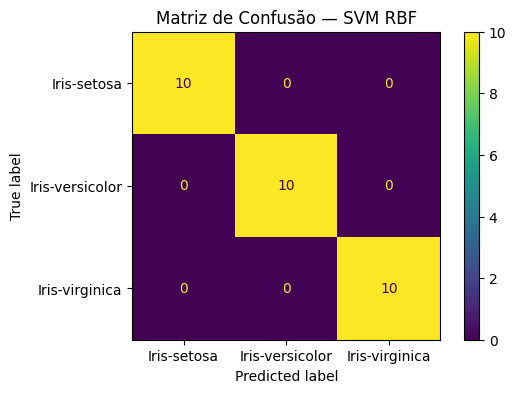

In [5]:
pipeline_rbf = Pipeline([
    ('escalonador', StandardScaler()),
    ('modelo_svm', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))
])

# Treino e previsão
pipeline_rbf.fit(X_train, y_train)
previsoes_rbf = pipeline_rbf.predict(X_test)

# Métrica de desempenho
acuracia_rbf = accuracy_score(y_test, previsoes_rbf)
print(f"Acurácia do SVM RBF no teste: {acuracia_rbf * 100:.2f}%")

# Plotando a Matriz de Confusão para ver onde o modelo errou ou acertou
matriz_confusao = confusion_matrix(y_test, previsoes_rbf)
visualizacao = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao, display_labels=pipeline_rbf.classes_)
visualizacao.plot()
plt.title("Matriz de Confusão — SVM RBF")
plt.show()

---
# Validação Cruzada e Testando Outras Configurações (Tarefas da Aula)
Para ter certeza de que o modelo não deu "sorte" na divisão de teste, utilizo a Validação Cruzada (Cross-Validation) com 5 divisões (folds).

Também realizo os exercícios práticos propostos:

Testar o kernel polinomial (`kernel=poly`).
Testar a influência da variação do parâmetro `c`.

In [6]:
# Validação cruzada no SVM Linear e RBF (5 partes)
cv_linear = cross_val_score(pipeline_linear, X, y, cv=5)
cv_rbf = cross_val_score(pipeline_rbf, X, y, cv=5)

# Testando Kernel Polinomial
pipeline_poly = Pipeline([
    ('escalonador', StandardScaler()),
    ('modelo_svm', SVC(kernel='poly', degree=3, C=1.0, random_state=42))
])
pipeline_poly.fit(X_train, y_train)
acuracia_poly = accuracy_score(y_test, pipeline_poly.predict(X_test))

# Testando variações de 'C' no kernel RBF
resultados_c = {}
valores_c = [0.1, 1.0, 10.0, 100.0]

for c_val in valores_c:
    p = Pipeline([
        ('escalonador', StandardScaler()),
        ('modelo_svm', SVC(kernel='rbf', C=c_val, random_state=42))
    ])
    p.fit(X_train, y_train)
    acc = accuracy_score(y_test, p.predict(X_test))
    resultados_c[f"C = {c_val}"] = f"{acc * 100:.1f}%"

# Criando uma tabela para comparar os modelos principais
tabela_comparacao = pd.DataFrame({
    'Modelo': ['SVM Linear', 'SVM RBF', 'SVM Polinomial'],
    'Acurácia no Teste': [acuracia_linear, acuracia_rbf, acuracia_poly],
    'Média Validação Cruzada (CV)': [cv_linear.mean(), cv_rbf.mean(), cross_val_score(pipeline_poly, X, y, cv=5).mean()]
})

print("TABELA COMPARATIVA DE MODELOS")
display(tabela_comparacao)

print("\n TESTE DE VARIAÇÃO DO PARÂMETRO 'C' NO KERNEL RBF ")
print(resultados_c)

TABELA COMPARATIVA DE MODELOS


,Modelo,Acurácia no Teste,Média Validação Cruzada (CV)
0,SVM Linear,1.0,0.993333
1,SVM RBF,1.0,0.993333
2,SVM Polinomial,1.0,0.980000



 TESTE DE VARIAÇÃO DO PARÂMETRO 'C' NO KERNEL RBF 
{'C = 0.1': '100.0%', 'C = 1.0': '100.0%', 'C = 10.0': '100.0%', 'C = 100.0': '100.0%'}
